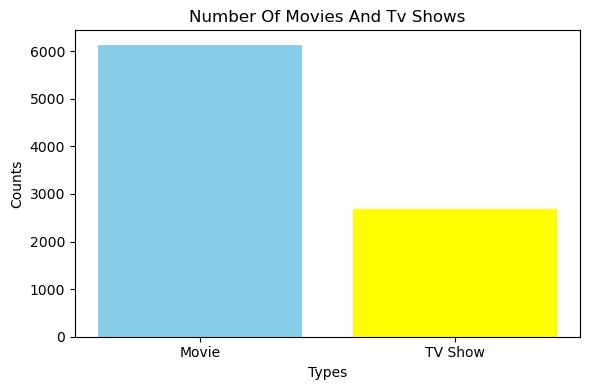

In [14]:
# Importing Libraries
import pandas as pd
import matplotlib.pyplot as plt

# Load Dataset
df = pd.read_csv(r"netflix_titles.csv")

# Data clean
# df = df.dropna(subset=['type','release_year','rating','country','duration'])
# print(df)

# Line Plot for Comparing Movies And Tv Shows
type_counts = df['type'].value_counts()
plt.figure(figsize=(6,4))
plt.bar(type_counts.index,type_counts.values,color=['skyblue','yellow'])
plt.title("Number Of Movies And Tv Shows")
plt.xlabel("Types")
plt.ylabel("Counts")
plt.tight_layout()
plt.savefig("Movies_vs_Tvshows.png")
plt.show()




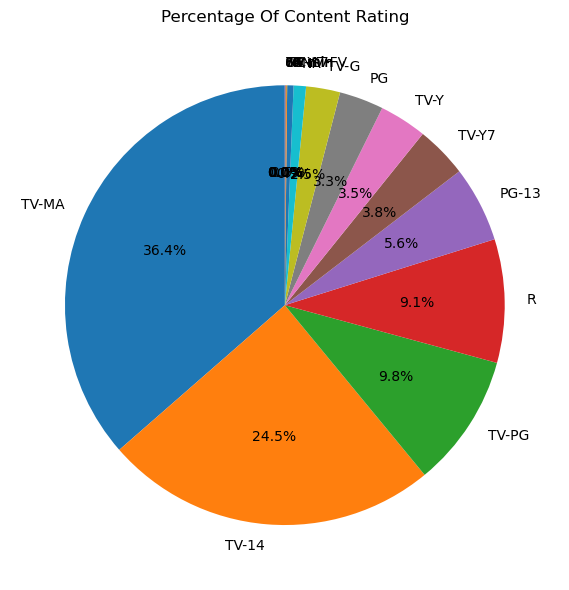

In [15]:
# Pie chart for showing percentage of content rating
rating_counts = df['rating'].value_counts()
plt.figure(figsize=(8,6))
plt.pie(rating_counts,labels=rating_counts.index,autopct='%1.1f%%',startangle=90)
plt.title("Percentage Of Content Rating")
plt.tight_layout()
plt.savefig("Content_Rating_pie.png")
plt.show()


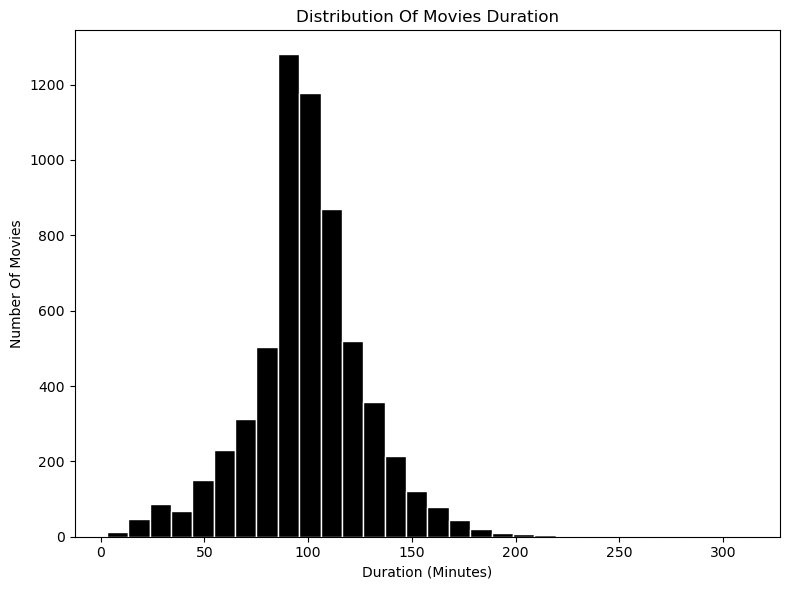

In [20]:
# Histogram for movies duaration
movie_df = df[df['type'] == 'Movie'].copy()

# Remove rows with missing duration values and convert to integer
movie_df = movie_df.dropna(subset=['duration'])  # Remove rows where duration is NaN
movie_df['duration_int'] = movie_df['duration'].str.replace('min','').astype(int)

plt.figure(figsize=(8,6))
plt.hist(movie_df['duration_int'],bins=30,color='Black',edgecolor='White')
plt.title("Distribution Of Movies Duration")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Number Of Movies")
plt.tight_layout()
plt.savefig("Movie_Duration_Histogram.png")
plt.show()

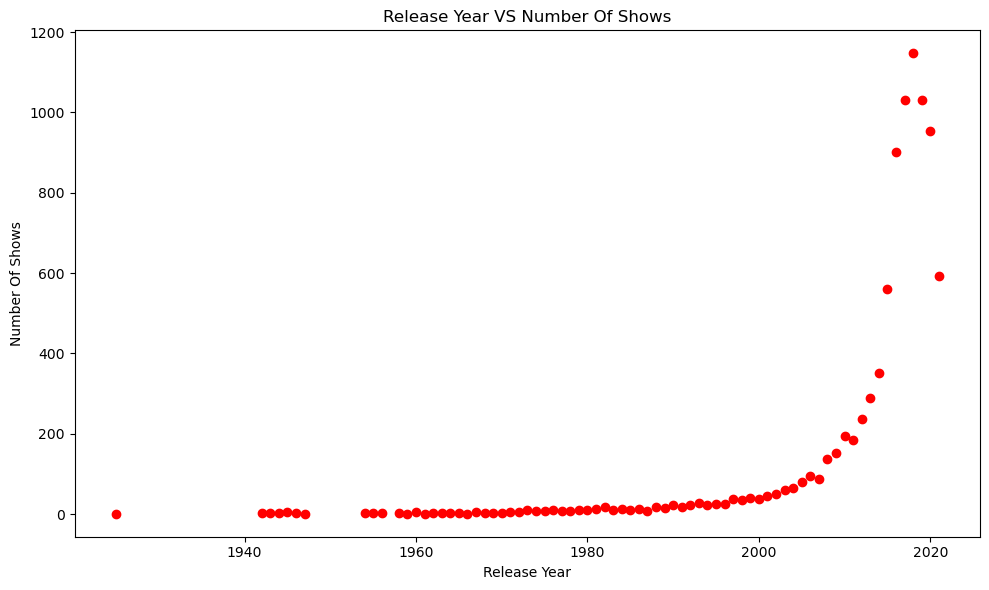

In [22]:
# Scatter Plot For Visualising Release Year Vs Number OF Shows
release_counts = df['release_year'].value_counts().sort_index()
plt.figure(figsize=(10,6))
plt.scatter(release_counts.index,release_counts.values,color='red')
plt.title("Release Year VS Number Of Shows")
plt.xlabel("Release Year")
plt.ylabel("Number Of Shows")
plt.tight_layout()
plt.savefig("Release_Year_Scatter.png")
plt.show()

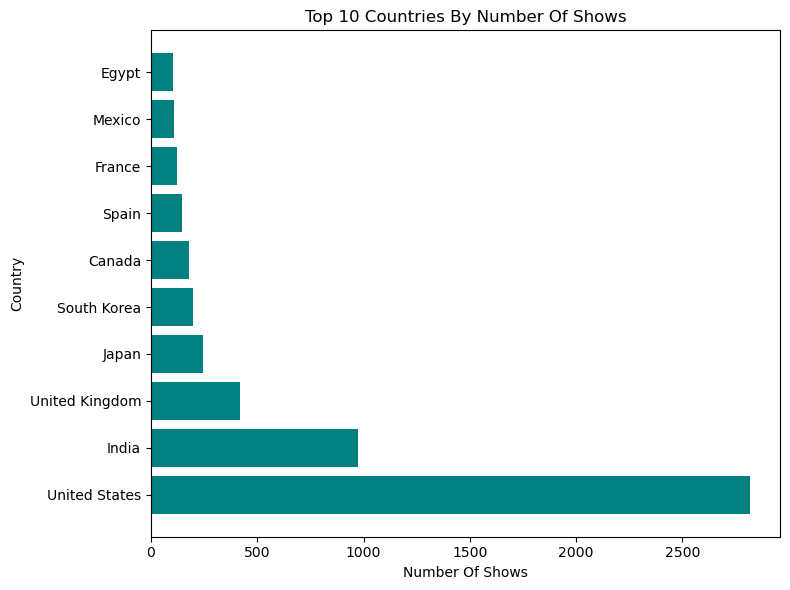

In [24]:
# Horizontal Bar Chart For Represent Top 10 Countries By Number Of Shows
Country_counts = df['country'].value_counts().head(10)
plt.figure(figsize=(8,6))
plt.barh(Country_counts.index,Country_counts.values,color="teal")
plt.title("Top 10 Countries By Number Of Shows")
plt.xlabel("Number Of Shows")
plt.ylabel("Country")
plt.tight_layout()
plt.savefig("Top10_Countries_Bar.png")
plt.show()

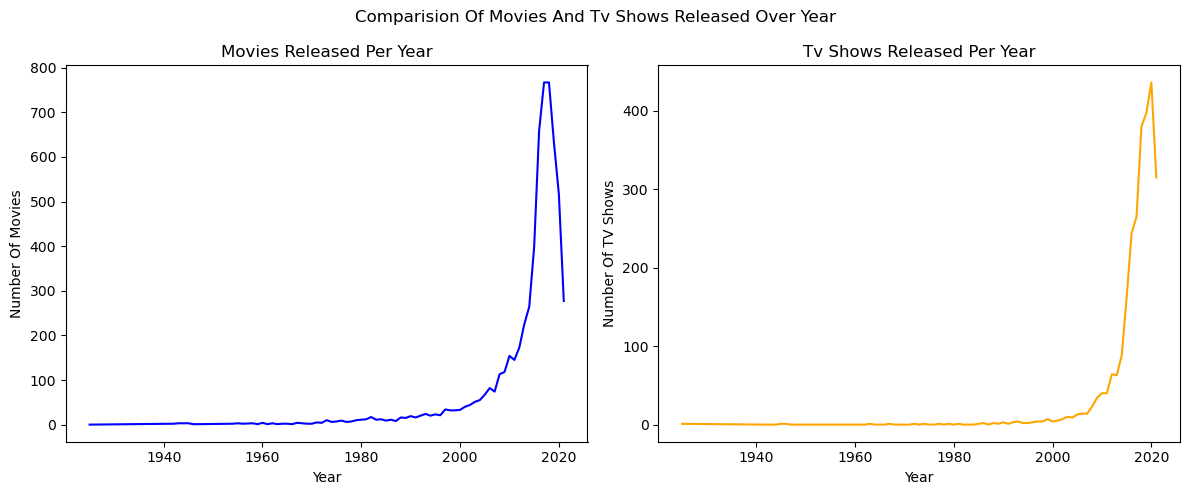

In [31]:
# Subplot Movie Shows And Tv Shows By Year
# First : Movies

content_by_year = df.groupby(['release_year','type']).size().unstack().fillna(0)

fig, ax = plt.subplots(1,2,figsize=(12,5))

ax[0].plot(content_by_year.index,content_by_year['Movie'],color='blue')
ax[0].set_title("Movies Released Per Year")
ax[0].set_xlabel("Year")
ax[0].set_ylabel("Number Of Movies")

# Second : TV Shows

ax[1].plot(content_by_year.index,content_by_year['TV Show'],color='orange')
ax[1].set_title("Tv Shows Released Per Year")
ax[1].set_xlabel("Year")
ax[1].set_ylabel("Number Of TV Shows")

fig.suptitle("Comparision Of Movies And Tv Shows Released Over Year")

plt.tight_layout()
plt.savefig("Movies_Tv_Shows_Comparision_Subplot.png")
plt.show()